# 02 - EDA & Feature Preparation for HMM

## Project: Crypto Market Regime Detection using Hidden Markov Models

This notebook explores the distribution of our 6 engineered features and prepares them (standardization) for the Hidden Markov Model.

**Features analyzed:**
- `log_return` — Daily logarithmic returns
- `volatility_7d` — Rolling volatility (7-day window)
- `volatility_21d` — Rolling volatility (21-day window)
- `rsi` — Relative Strength Index (14-day)
- `macd_diff` — MACD Histogram (momentum acceleration)
- `volume_norm` — Normalized volume (relative to 21-day average)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')


btc = pd.read_csv('../data/raw/btc_features_clean.csv', index_col='Date', parse_dates=True)
print("Shape:", btc.shape)
print("Columnas:", btc.columns.tolist())
btc.head()


Shape: (2957, 6)
Columnas: ['log_returns', 'volatility_7d', 'volatility_21d', 'rsi', 'macd_diff', 'volume_norm']


,log_returns,volatility_7d,volatility_21d,rsi,macd_diff,volume_norm
Date,,,,,,
2018-02-03,0.038233,0.061780,0.065664,32.239444,-163.009059,0.670665
2018-02-04,-0.102991,0.060185,0.067935,28.425279,-201.033728,0.664822
2018-02-05,-0.173982,0.075770,0.074986,23.936093,-289.724266,0.886446
2018-02-06,0.108709,0.097847,0.072556,31.025208,-269.538122,1.366689
2018-02-07,-0.017262,0.096035,0.072534,30.516343,-240.995738,0.937216


### 2.1 Feature Distributions

/tmp/ipykernel_12775/4071290497.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)


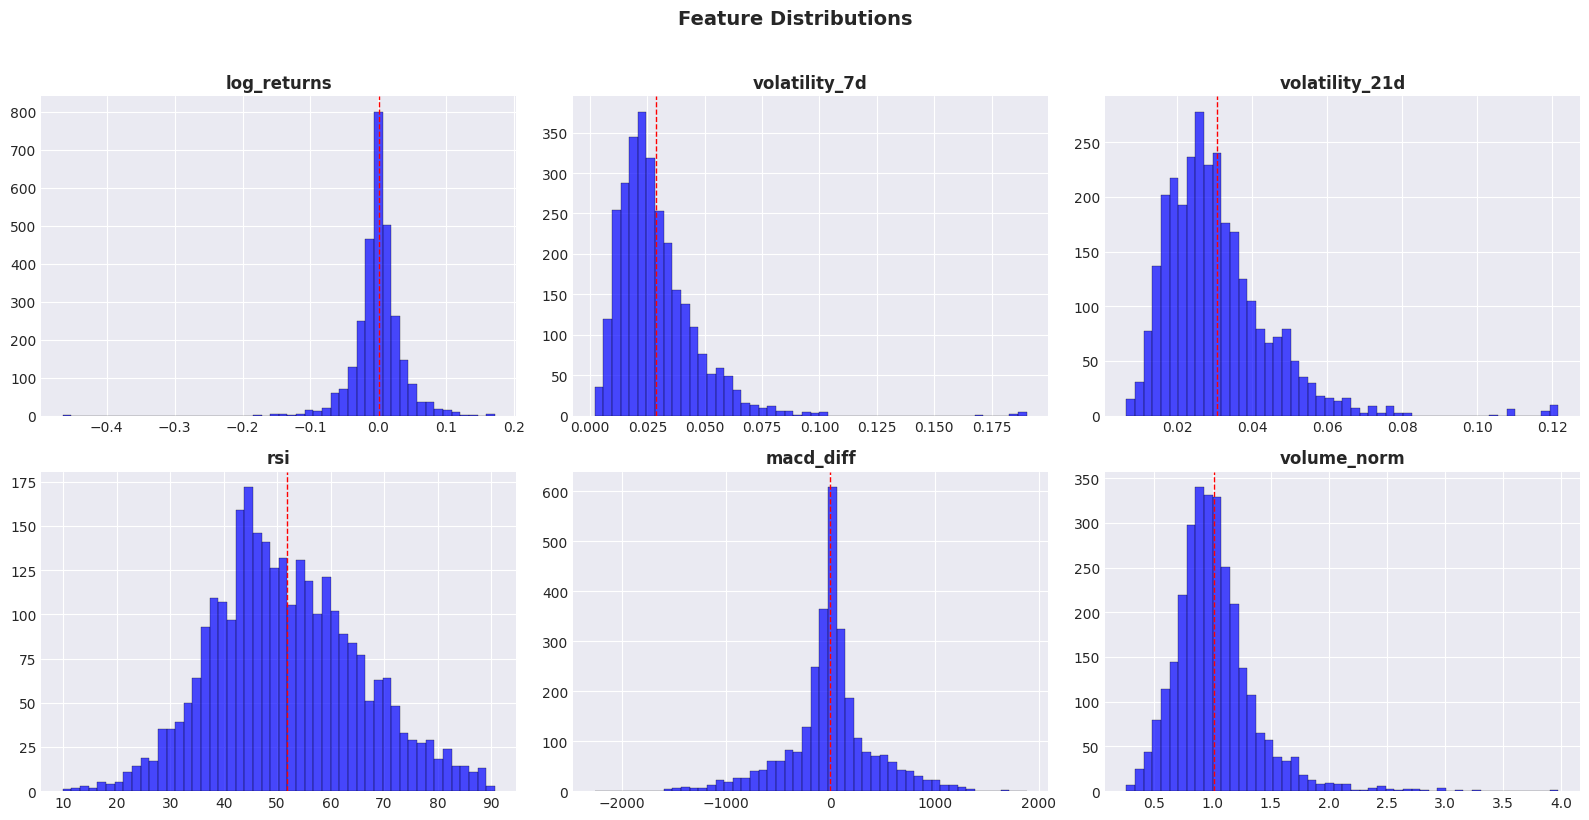

In [13]:
fig, axes = plt.subplots(2,3,figsize=(16,8))
axes = axes.flatten()
for i, col in enumerate(btc.columns):
    axes[i].hist(btc[col], bins=50, color='blue', alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].axvline(btc[col].mean(), color='red', linestyle='--', linewidth=1)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** We can see that the distributions have positive biases, which is normal and what we expected. Now the distribution does show a need for standardization. This is mainly due to the data scales, and in the HMM model we want no category to have more weight than another, so we will seek to standardize. 

In [14]:
scaler = StandardScaler()
btc_scaled = pd.DataFrame(scaler.fit_transform(btc),columns=btc.columns,index=btc.index)

print("Data standardize: ")
btc_scaled.describe()

Data standardize: 


,log_returns,volatility_7d,volatility_21d,rsi,macd_diff,volume_norm
count,2.957000e+03,2.957000e+03,2.957000e+03,2.957000e+03,2.957000e+03,2.957000e+03
mean,8.410212e-18,5.767002e-17,1.153400e-16,-2.883501e-17,9.611670e-18,-1.441751e-17
std,1.000169e+00,1.000169e+00,1.000169e+00,1.000169e+00,1.000169e+00,1.000169e+00
min,-1.380512e+01,-1.551124e+00,-1.686459e+00,-3.055750e+00,-5.299142e+00,-2.229180e+00
25%,-4.223039e-01,-6.479238e-01,-6.760637e-01,-6.800588e-01,-3.660865e-01,-6.044398e-01
50%,-2.064531e-03,-2.093813e-01,-1.750435e-01,-8.730974e-02,1.490600e-02,-1.208632e-01
75%,4.246136e-01,4.191167e-01,4.134729e-01,6.601560e-01,3.631551e-01,4.416418e-01
max,5.075770e+00,9.304789e+00,6.347243e+00,2.836188e+00,4.416820e+00,8.746052e+00


/tmp/ipykernel_12775/1337874217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)


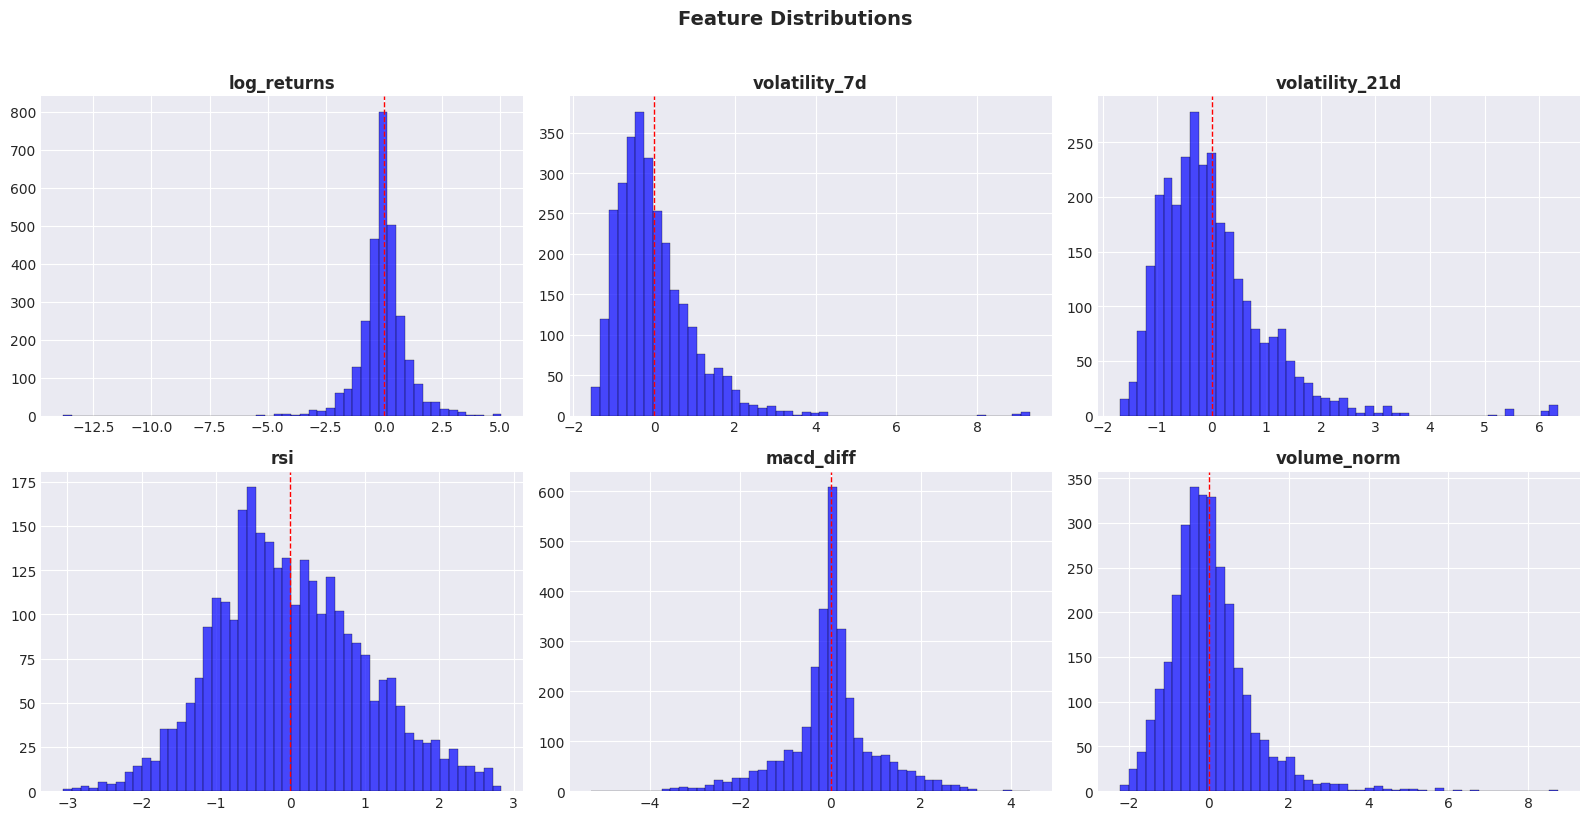

In [15]:
fig, axes = plt.subplots(2,3,figsize=(16,8))
axes = axes.flatten()
for i, col in enumerate(btc_scaled.columns):
    axes[i].hist(btc_scaled[col], bins=50, color='blue', alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].axvline(btc_scaled[col].mean(), color='red', linestyle='--', linewidth=1)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Save Standardized Dataset

Saving both the scaler (for future inverse transforms) and the standardized features ready for the HMM.

In [17]:
import joblib
joblib.dump(scaler, '../data/raw/feature_scaler.pkl')
btc_scaled.to_csv('../data/raw/btc_features_scaled.csv')